<a href="https://colab.research.google.com/github/Pasinduimalsha/Finetuning-LLM/blob/main/Fine_tune_Llama_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Step 1: Install All the Required Packages**

In [1]:
# Clean install bitsandbytes
!pip uninstall -y bitsandbytes
!pip install -U bitsandbytes

# Install modern, pre-compiled versions of the ecosystem
!pip install -U transformers tokenizers accelerate peft trl datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


#**Step 2: Import All the Required Libraries**

In [2]:
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    HfArgumentParser,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig

#**In case of Llama 2, the following prompt template is used for the chat models**

System Prompt (optional) to guide the model


User prompt (required) to give the instruction


Model Answer (required)

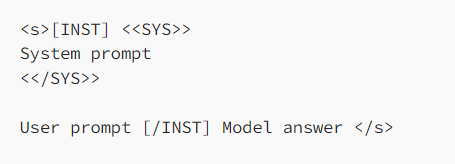

#We will reformat our instruction dataset to follow Llama 2 template.

- Orignal Dataset: https://huggingface.co/datasets/timdettmers/openassistant-guanaco

- Reformat Dataset following the Llama 2 template with 1k sample: https://huggingface.co/datasets/mlabonne/guanaco-llama2-1k

- Complete Reformat Dataset following the Llama 2 template: https://huggingface.co/datasets/mlabonne/guanaco-llama2

To know how this dataset was created, you can check this notebook.  

https://colab.research.google.com/drive/1Ad7a9zMmkxuXTOh1Z7-rNSICA4dybpM2?usp=sharing

### Note: You don’t need to follow a specific prompt template if you’re using the base Llama 2 model instead of the chat version.

#**How to fine tune Llama 2**

- Free Google Colab offers a 15GB Graphics Card (Limited Resources --> Barely enough to store Llama 2–7b’s weights)

- We also need to consider the overhead due to optimizer states, gradients, and forward activations

- Full fine-tuning is not possible here: we need parameter-efficient fine-tuning (PEFT) techniques like LoRA or QLoRA.

- To drastically reduce the VRAM usage, we must fine-tune the model in 4-bit precision, which is why we’ll use QLoRA here.

#**Step 3**

1. Load a llama-2-7b-chat-hf model (chat model)
2. Train it on the mlabonne/guanaco-llama2-1k (1,000 samples), which will produce our fine-tuned model Llama-2-7b-chat-finetune

QLoRA will use a rank of 64 with a scaling parameter of 16. We’ll load the Llama 2 model directly in 4-bit precision using the NF4 type and train it for one epoch

In [3]:
# The model that you want to train from the Hugging Face hub
model_name = "NousResearch/Llama-2-7b-chat-hf"

# The instruction dataset to use
dataset_name = "mlabonne/guanaco-llama2-1k"

# Fine-tuned model name
new_model = "Llama-2-7b-chat-finetune"

################################################################################
# QLoRA parameters
################################################################################

# LoRA attention dimension
lora_r = 64

# Alpha parameter for LoRA scaling
lora_alpha = 16

# Dropout probability for LoRA layers
lora_dropout = 0.1

################################################################################
# bitsandbytes parameters
################################################################################

# Activate 4-bit precision base model loading
use_4bit = True

# Compute dtype for 4-bit base models
bnb_4bit_compute_dtype = "float16"

# Quantization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# Activate nested quantization for 4-bit base models (double quantization)
use_nested_quant = False

################################################################################
# TrainingArguments parameters
################################################################################

# Output directory where the model predictions and checkpoints will be stored
output_dir = "./results"

# Number of training epochs
num_train_epochs = 1

# Enable fp16/bf16 training (set bf16 to True with an A100)
fp16 = False
bf16 = False

# Batch size per GPU for training
per_device_train_batch_size = 4

# Batch size per GPU for evaluation
per_device_eval_batch_size = 4

# Number of update steps to accumulate the gradients for
gradient_accumulation_steps = 1

# Enable gradient checkpointing
gradient_checkpointing = True

# Maximum gradient normal (gradient clipping)
max_grad_norm = 0.3

# Initial learning rate (AdamW optimizer)
learning_rate = 2e-4

# Weight decay to apply to all layers except bias/LayerNorm weights
weight_decay = 0.001

# Optimizer to use
optim = "paged_adamw_32bit"

# Learning rate schedule
lr_scheduler_type = "cosine"

# Number of training steps (overrides num_train_epochs)
max_steps = -1

# Ratio of steps for a linear warmup (from 0 to learning rate)
warmup_ratio = 0.03

# Group sequences into batches with same length
# Saves memory and speeds up training considerably
group_by_length = True

# Save checkpoint every X updates steps
save_steps = 0

# Log every X updates steps
logging_steps = 25

################################################################################
# SFT parameters
################################################################################

# Maximum sequence length to use
max_seq_length = None

# Pack multiple short examples in the same input sequence to increase efficiency
packing = False

# Load the entire model on the GPU 0
device_map = {"": 0}

In [4]:
import torch
import gc

# Delete any old model or trainer instances if they exist
if 'trainer' in locals(): del trainer
if 'model' in locals(): del model
gc.collect()

# Clear the PyTorch CUDA cache
torch.cuda.empty_cache()
print("GPU Memory Cleared!")

GPU Memory Cleared!


#**Step 4:Load everything and start the fine-tuning process**

1. First of all, we want to load the dataset we defined. Here, our dataset is already preprocessed but, usually, this is where you would reformat the prompt, filter out bad text, combine multiple datasets, etc.


2. Then, we’re configuring bitsandbytes for 4-bit quantization.


3. Next, we're loading the Llama 2 model in 4-bit precision on a GPU with the corresponding tokenizer.


4. Finally, we're loading configurations for QLoRA, regular training parameters, and passing everything to the SFTTrainer. The training can finally start!

In [5]:
# Load dataset (you can process it here)
dataset = load_dataset(dataset_name, split="train")

# Load tokenizer and model with QLoRA configuration
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

# Check GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
    major, _ = torch.cuda.get_device_capability()
    if major >= 8:
        print("=" * 80)
        print("Your GPU supports bfloat16: accelerate training with bf16=True")
        print("=" * 80)

# Load base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)
model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # Fix weird overflow issue with fp16 training

# Load LoRA configuration
peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM",
)

# 2. Modern, Unified SFTConfig (Combines TrainingArguments & Dataset settings)
sft_config = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    save_steps=save_steps,
    logging_steps=logging_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    fp16=fp16,
    bf16=bf16,
    max_grad_norm=max_grad_norm,
    max_steps=max_steps,
    warmup_steps=10,
    lr_scheduler_type=lr_scheduler_type,
    report_to="tensorboard",

    # Unified TRL specific parameters
    dataset_text_field="text",
    max_length=512 if max_seq_length is None else max_seq_length, # Renamed from max_seq_length
    packing=packing,
)

# 3. Initialize SFTTrainer cleanly
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    processing_class=tokenizer, # Renamed from tokenizer
    args=sft_config,            # Single config passed here
)

# Train model
trainer.train()

README.md:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

data/train-00000-of-00001-9ad84bb9cf65a4(…):   0%|          | 0.00/967k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

...

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
25,1.668285
50,1.340780
75,1.337316
100,1.383165
125,1.252821
150,1.265412
175,1.268587
200,1.303984
225,1.228820
250,1.234687


TrainOutput(global_step=250, training_loss=1.328385643005371, metrics={'train_runtime': 1407.4284, 'train_samples_per_second': 0.711, 'train_steps_per_second': 0.178, 'total_flos': 1.9542250376626176e+16, 'train_loss': 1.328385643005371, 'epoch': 1.0})

In [6]:
from huggingface_hub import login

login()

In [ ]:
trainer.model.save_pretrained("my-model")
tokenizer.save_pretrained("my-model")

In [8]:
trainer.model.push_to_hub("PasinduM/Llama-2-7b-chat-finetunet")
tokenizer.push_to_hub("PasinduM/Llama-2-7b-chat-finetune")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|1         |  716kB / 67.1MB            

CommitInfo(commit_url='https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune/commit/adf177006096b99b09091db09461bf7bdb9dccc5', commit_message='Upload tokenizer', commit_description='', oid='adf177006096b99b09091db09461bf7bdb9dccc5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune', endpoint='https://huggingface.co', repo_type='model', repo_id='PasinduM/Llama-2-7b-chat-finetune'), pr_revision=None, pr_num=None)

In [16]:
model.push_to_hub("PasinduM/Llama-2-7b-chat-finetune")

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...5j7gcrv/model.safetensors:   0%|          | 14.9MB / 4.23GB            

CommitInfo(commit_url='https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune/commit/86e0265cb9abdd2afb680bdf11b9916bfdf32e8a', commit_message='Upload LlamaForCausalLM', commit_description='', oid='86e0265cb9abdd2afb680bdf11b9916bfdf32e8a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune', endpoint='https://huggingface.co', repo_type='model', repo_id='PasinduM/Llama-2-7b-chat-finetune'), pr_revision=None, pr_num=None)

In [20]:
from peft import PeftModel
from transformers import AutoModelForCausalLM

# Load local adapter
base = AutoModelForCausalLM.from_pretrained("NousResearch/Llama-2-7b-chat-hf")
model = PeftModel.from_pretrained(base, "/content/results/checkpoint-250")

# Push directly to the main root of your HF repo
model.push_to_hub("PasinduM/Llama-2-7b-chat-finetune")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/5.18k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|          | 1.22MB /  134MB            

CommitInfo(commit_url='https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune/commit/aa96d3331a93ef2ee9b80506156a05bb265a113d', commit_message='Upload model', commit_description='', oid='aa96d3331a93ef2ee9b80506156a05bb265a113d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune', endpoint='https://huggingface.co', repo_type='model', repo_id='PasinduM/Llama-2-7b-chat-finetune'), pr_revision=None, pr_num=None)

In [22]:
from transformers import AutoModelForCausalLM
from peft import PeftModel

# 1. Load the base model from HF
base_model = AutoModelForCausalLM.from_pretrained(
    "NousResearch/Llama-2-7b-chat-hf"
)

# 2. Load your adapter LOCALLY from your Colab storage
model = PeftModel.from_pretrained(
    base_model,
    "/content/results/checkpoint-250" # <-- Local path, NOT the Hugging Face repo string
)

# 3. Push it to your Hugging Face account so it saves permanently
model.push_to_hub("PasinduM/Llama-2-7b-chat-finetune")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  12%|#1        | 16.0MB /  134MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune/commit/aa96d3331a93ef2ee9b80506156a05bb265a113d', commit_message='Upload model', commit_description='', oid='aa96d3331a93ef2ee9b80506156a05bb265a113d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/PasinduM/Llama-2-7b-chat-finetune', endpoint='https://huggingface.co', repo_type='model', repo_id='PasinduM/Llama-2-7b-chat-finetune'), pr_revision=None, pr_num=None)

In [19]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


**TEST 01- Using a trained tokernizer**

In [24]:
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(
    "NousResearch/Llama-2-7b-chat-hf"
)

tokenizer = AutoTokenizer.from_pretrained(
    "PasinduM/Llama-2-7b-chat-finetune"
)

model = PeftModel.from_pretrained(
    base_model,
    "PasinduM/Llama-2-7b-chat-finetune"
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/134M [00:00<?, ?B/s]

In [26]:
prompt = "Explain machine learning in simple words."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=200
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

KeyboardInterrupt: 

In [27]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

pipe("Tell me about Sri Lanka.")

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 7.81 MiB is free. Including non-PyTorch memory, this process has 14.53 GiB memory in use. Of the allocated memory 14.16 GiB is allocated by PyTorch, and 245.79 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)